In [ ]:
import sys
sys.dont_write_bytecode = True
from notebooks._init_notebook import *
sys.dont_write_bytecode = False

In [19]:
BASE_PATH = "../data/yahoo_1d"
loaded_pct_changes = []

def normalize_symbol(symbol: str) -> str:
    # Reemplaza caracteres problemáticos para que coincidan con archivos
    return symbol.replace("^", "").replace("/", "-")

# Excluimos criptos por operar los fines de semana
for group, assets in SYMBOL_GROUPS_YAHOO.items():
    if group == "cripto":
        continue

    for symbol in assets:
        normalized_symbol = normalize_symbol(symbol)
        file_path = os.path.join(BASE_PATH, group, f"{normalized_symbol}.csv")
        if not os.path.exists(file_path):
            print(f"Archivo no encontrado: {file_path}")
            continue

        try:
            df = pd.read_csv(file_path, skiprows=[1])
            df.columns = ['Date', f'{symbol}.Close', f'{symbol}.High', f'{symbol}.Low',
                          f'{symbol}.Open', f'{symbol}.Volume']
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.set_index('Date').sort_index()

            df = calc_pct_change(df, name=symbol)
            pct_col = df[[f'{symbol}.PctChange']]
            loaded_pct_changes.append(pct_col)

        except Exception as e:
            print(f"Error procesando {symbol}: {e}")

# Combinar todo por fecha
if loaded_pct_changes:
    pct_change_matrix = pd.concat(loaded_pct_changes, axis=1).dropna()
    #print("Columnas en la matriz de pct_change:")
    #print(pct_change_matrix.columns)
    #print(pct_change_matrix.head())
else:
    print("No se cargaron datos.")

#pct_change_matrix.head()

In [20]:
start_date = pd.Timestamp('2013-01-07')
pct_change_matrix = pct_change_matrix[pct_change_matrix.index >= start_date]

lags = [1, 2, 7]

pct_change_lags = []

for lag in lags:
    lagged = pct_change_matrix.shift(lag)
    # Renombrar columnas para indicar el lag
    lagged.columns = [f"{col}.lag{lag}" for col in lagged.columns]
    pct_change_lags.append(lagged)

# Concatenamos todas las columnas rezagadas
pct_change_features = pd.concat(pct_change_lags, axis=1)

In [21]:
target_symbol = "^GSPC"  # Ajustar según tu símbolo

# Sacamos el pct_change original del SP500 (sin lag)
target = pct_change_matrix[f"{target_symbol}.PctChange"]

In [22]:
# Unión (features tienen lag, target es día t)
df_ml = pct_change_features.join(target, how='inner')

# Sacar filas con NA
df_ml = df_ml.dropna()

# Separar X e y
X = df_ml.drop(columns=[f"{target_symbol}.PctChange"])
y = df_ml[f"{target_symbol}.PctChange"]

# División 80%-20%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # No shuffle para mantener orden temporal
)

In [23]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

model = MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.001, max_iter=2000,
                     early_stopping=False, random_state=20)

model.fit(X_train, y_train)

# Predicción y evaluación
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE test: {mse:.5f}")

MSE test: 1.51847


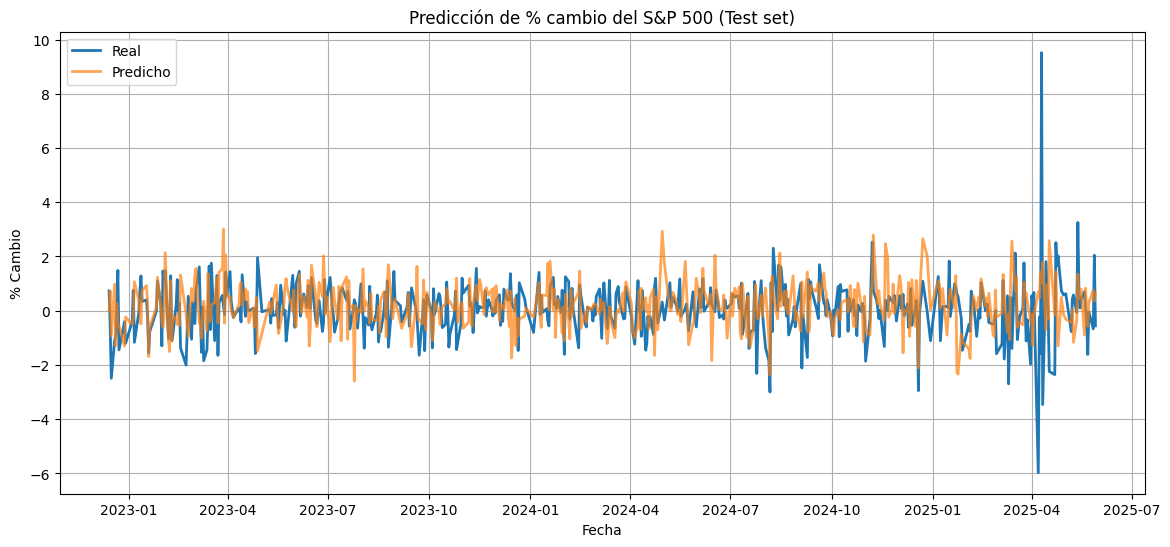

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Real', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicho', linewidth=2, alpha=0.7)
plt.title('Predicción de % cambio del S&P 500 (Test set)')
plt.xlabel('Fecha')
plt.ylabel('% Cambio')
plt.legend()
plt.grid(True)
plt.show()

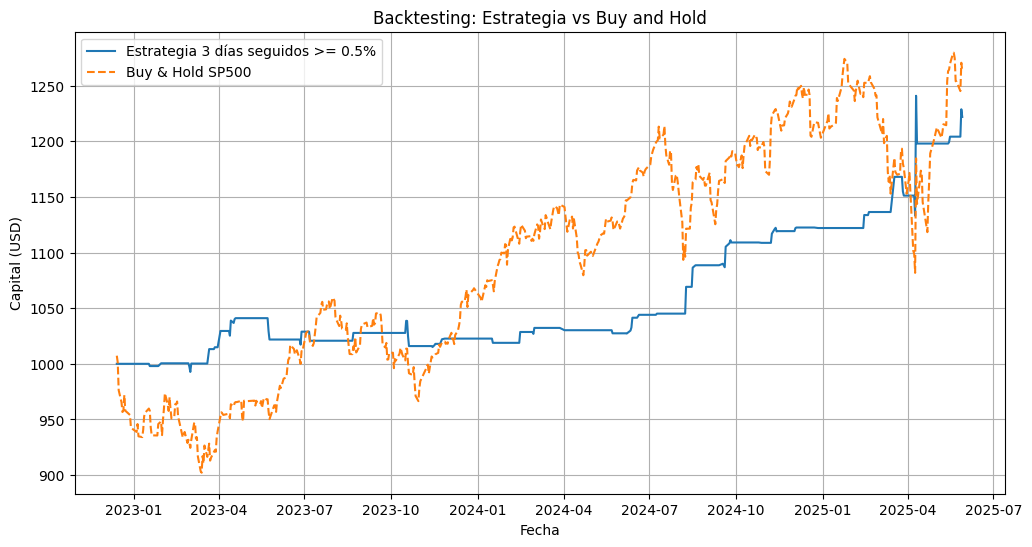

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir la señal booleana a pd.Series para usar shift
signal_bool = pd.Series(y_pred >= 0.10, index=y_test.index)

# Crear señal para 3 días consecutivos con predicción >= 0.5%
signal_3dias = signal_bool & signal_bool.shift(1) & signal_bool.shift(2)

# Convertir señal a int (1 si cumple, 0 si no)
signal = signal_3dias.astype(int)

# Retorno real diario en decimal (transformar % a factor)
returns_real = y_test / 100

# Retorno diario de la estrategia = señal * retorno real del día
strategy_returns = signal * returns_real

# Capital inicial
capital = 1000

# Calcular equity acumulado con capital inicial
equity_curve_strategy = (1 + strategy_returns).cumprod() * 1000
equity_curve_bh = (1 + returns_real).cumprod() * 1000

# DataFrame resumen
df_backtest = pd.DataFrame({
    'Real_Returns_%': y_test,
    'Predicted_Returns_%': y_pred,
    'Signal': signal,
    'Strategy_Returns': strategy_returns,
    'Equity_Strategy': equity_curve_strategy,
    'Equity_BuyHold': equity_curve_bh
})

# Gráfico
plt.figure(figsize=(12,6))
plt.plot(df_backtest.index, df_backtest['Equity_Strategy'], label='Estrategia 3 días seguidos >= 0.5%')
plt.plot(df_backtest.index, df_backtest['Equity_BuyHold'], label='Buy & Hold SP500', linestyle='--')
plt.title('Backtesting: Estrategia vs Buy and Hold')
plt.xlabel('Fecha')
plt.ylabel('Capital (USD)')
plt.grid(True)
plt.legend()
plt.show()

In [26]:
from sklearn.neural_network import MLPRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

capital_inicial = 1000
mejor_equity_final = 0
mejor_seed = None
mejor_modelo = None
resultados = []

for seed in range(100):
    model = MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.001,
                         max_iter=2000, early_stopping=False, random_state=seed)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Backtesting simple con condición: y_pred >= 0.5% ---
    signal = pd.Series(y_pred, index=y_test.index) >= 0.10
    signal = signal.astype(int)
    returns_real = y_test / 100
    strategy_returns = signal * returns_real
    equity_curve = (1 + strategy_returns).cumprod() * capital_inicial
    equity_final = equity_curve.iloc[-1]

    mse = mean_squared_error(y_test, y_pred)
    resultados.append({
        'seed': seed,
        'mse': mse,
        'equity_final': equity_final
    })

    if equity_final > mejor_equity_final:
        mejor_equity_final = equity_final
        mejor_seed = seed
        mejor_modelo = model
        mejor_y_pred = y_pred

# Mostrar resultados ordenados por capital final
df_resultados = pd.DataFrame(resultados).sort_values(by='equity_final', ascending=False)
print(df_resultados.head(10))
print(f"\n🔝 Mejor modelo - Seed: {mejor_seed}, Capital final: ${mejor_equity_final:.2f}")

    seed       mse  equity_final
20    20  1.518472   1512.999668
31    31  1.442363   1495.635490
78    78  1.460897   1400.986552
4      4  1.722149   1390.157808
55    55  1.625756   1382.933364
79    79  1.638522   1369.163434
66    66  1.671163   1357.625017
86    86  1.548998   1354.177241
95    95  1.747380   1344.432492
0      0  1.598678   1335.851876

🔝 Mejor modelo - Seed: 20, Capital final: $1513.00
